# Step 1. Import the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


In [2]:
sales_data = pd.read_csv(r'C:\Users\Akash\Desktop\All Datasets\sales_data.csv')

In [3]:
sales_data

,product_id,product_name,category,unit_sold,sale_date
0,1,Product 1,Clothing,12,2023-01-01
1,2,Product 2,Clothing,19,2023-01-02
2,3,Product 3,Clothing,15,2023-01-03
3,4,Product 4,Home,22,2023-01-04
4,5,Product 5,Clothing,27,2023-01-05
5,6,Product 6,Electronics,16,2023-01-06
6,7,Product 7,Home,23,2023-01-07
7,8,Product 8,Clothing,19,2023-01-08
8,9,Product 9,Home,23,2023-01-09
9,10,Product 10,Clothing,16,2023-01-10


# Descriptive Statistics

In [4]:
print("Descriptive Statistics for Unit Sold:")

print(sales_data.describe())

print()

mean_sales = (sales_data['unit_sold'].mean())
print(mean_sales)
median_sales =(sales_data['unit_sold'].median())
print(median_sales)
mode_sales = (sales_data['unit_sold'].mode()[0])
print(mode_sales)
std_sales = (sales_data['unit_sold'].std())
print(std_sales)
print(sales_data['unit_sold'].var())

print()

category_stats = sales_data.groupby('category')['unit_sold'].agg(['sum','mean','std']).reset_index()
category_stats.columns = ['category', 'Total Units Sold', 'Avg Unit Sold','Std Dev of Unit Sold']

print("Statistical Analysis")
print(category_stats)

Descriptive Statistics for Unit Sold:
       product_id  unit_sold
count    20.00000  20.000000
mean     10.50000  19.900000
std       5.91608   5.200202
min       1.00000  12.000000
25%       5.75000  15.750000
50%      10.50000  20.000000
75%      15.25000  23.000000
max      20.00000  31.000000

19.9
20.0
23
5.200202425209801
27.042105263157897

Statistical Analysis
      category  Total Units Sold  Avg Unit Sold  Std Dev of Unit Sold
0     Clothing               136      17.000000              4.750940
1  Electronics                68      22.666667              7.637626
2         Home               143      20.428571              3.457222
3       Sports                51      25.500000              3.535534


# Inferential Statistics

In [5]:
confidence_level = 0.95
degrees_freedom =  len(sales_data['unit_sold'])-1
sample_mean = mean_sales
sample_standard_error = std_sales/np.sqrt(len(sales_data['unit_sold']))

# T-Score for confidence Interval

t_score = stats.t.ppf((1+ confidence_level)/2, degrees_freedom)
margin_of_error = t_score * sample_standard_error


confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)
print("\n Confidence Interval for the Mean of Units Sold:")
print(confidence_interval)


 Confidence Interval for the Mean of Units Sold:
(np.float64(17.46623034870206), np.float64(22.33376965129794))


In [6]:
# Now we will check by changing the confidence_level

In [7]:
confidence_level = 0.99
degrees_freedom =  len(sales_data['unit_sold'])-1
sample_mean = mean_sales
sample_standard_error = std_sales/np.sqrt(len(sales_data['unit_sold']))

# T-Score for confidence Interval

t_score = stats.t.ppf((1+ confidence_level)/2, degrees_freedom)
margin_of_error = t_score * sample_standard_error


confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)
print("\n Confidence Interval for the Mean of Units Sold:")
print(confidence_interval)


 Confidence Interval for the Mean of Units Sold:
(np.float64(16.573303488862987), np.float64(23.22669651113701))


# Null Hypothesis Testing

In [8]:
t_statistics, p_value = stats.ttest_1samp(sales_data['unit_sold'], 20)

print("Hypothesis Testing (t-test):")

print(f"T-Statistics : {t_statistics}, P-value:  {p_value}")

if p_value>0.05:
    print("Reject the Null Hypothesis")
else:
    print("Accept the Null Hypothesis")

Hypothesis Testing (t-test):
T-Statistics : -0.08599926674622123, P-value:  0.932366807210202
Reject the Null Hypothesis


In [9]:
# Null Hypothesis is rejected

# Visualization

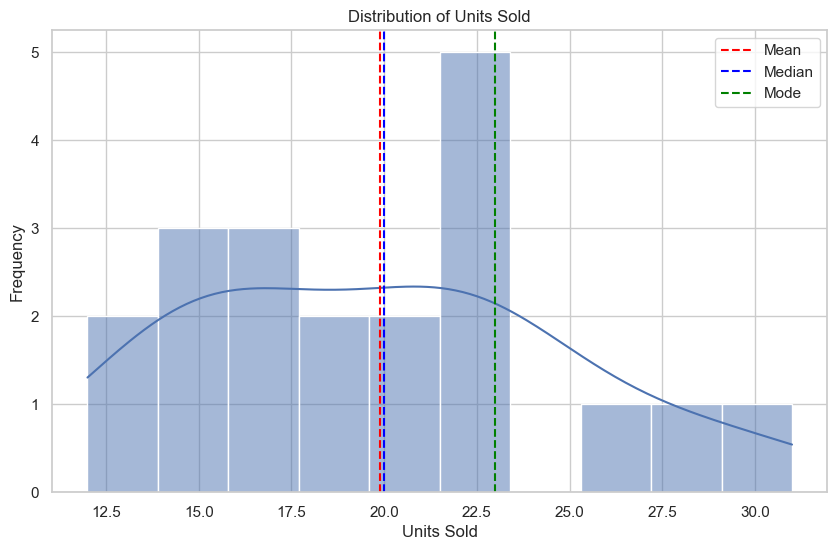

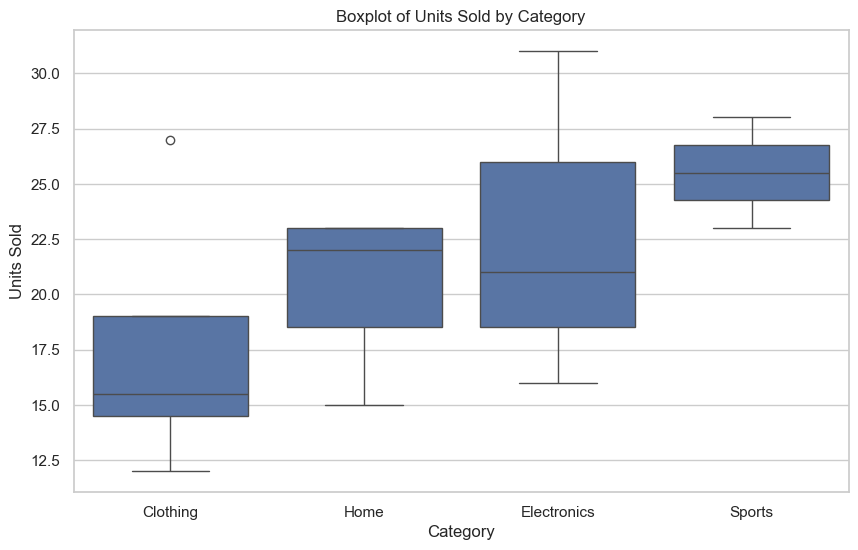

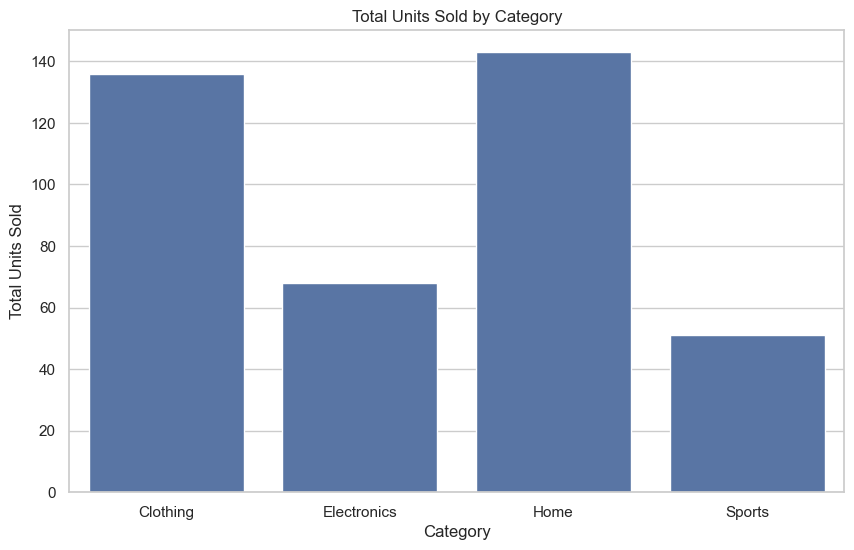

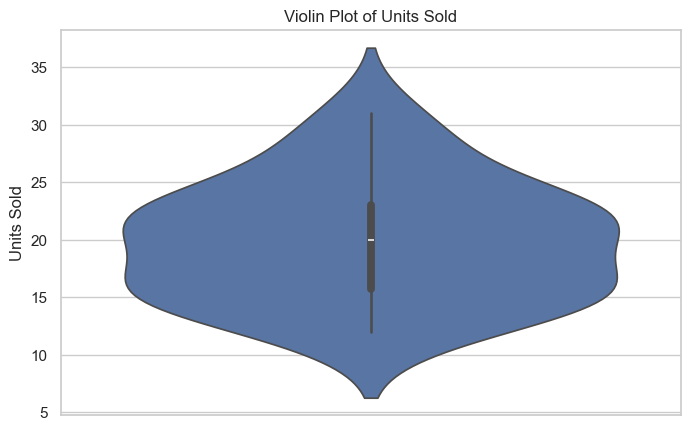

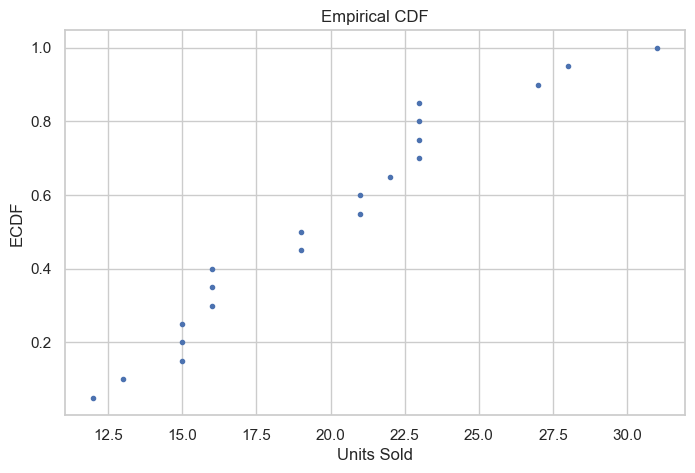

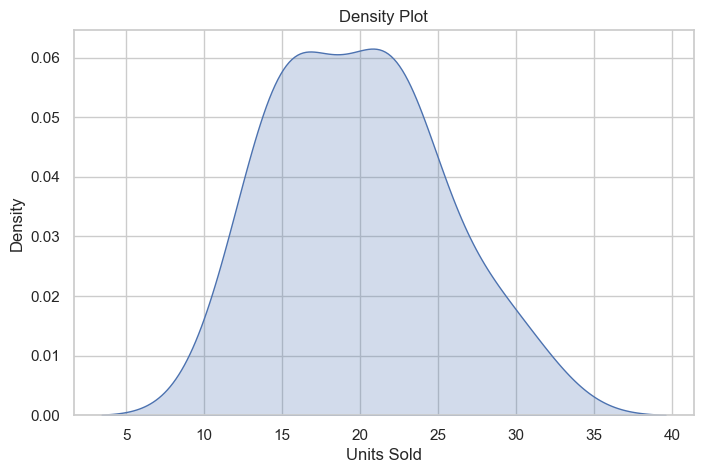

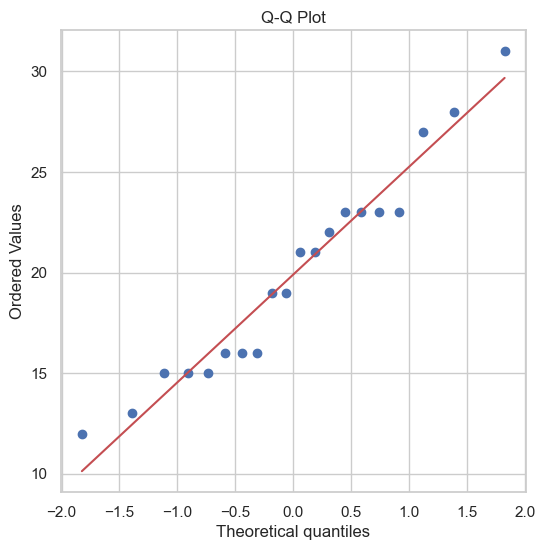

In [13]:
sns.set(style="whitegrid")

# Plot distribution of units sold
plt.figure(figsize=(10, 6))
sns.histplot(sales_data['unit_sold'], bins=10, kde=True)
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.axvline(mean_sales, color='red', linestyle='--', label='Mean')
plt.axvline(median_sales, color='blue', linestyle='--', label='Median')
plt.axvline(mode_sales, color='green', linestyle='--', label='Mode')
plt.legend()
plt.savefig("dist_plot.png", dpi=300, bbox_inches="tight")
plt.show()


# Boxplot for units sold by category
plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='unit_sold', data=sales_data)
plt.title('Boxplot of Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Units Sold')
plt.savefig("box_plot.png", dpi=300, bbox_inches="tight")
plt.show()


# Bar plot for total units sold by category
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='Total Units Sold', data=category_stats)
plt.title('Total Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.savefig("bar_plot.png", dpi=300, bbox_inches="tight")
plt.show()



# Violin Plot
plt.figure(figsize=(8,5))
sns.violinplot(y=sales_data['unit_sold'])
plt.title("Violin Plot of Units Sold")
plt.ylabel("Units Sold")
plt.savefig("violin_plot.png", dpi=300, bbox_inches="tight")
plt.show()


# ECDF (Empirical Cumulative Distribution)
plt.figure(figsize=(8,5))
x = np.sort(sales_data['unit_sold'])
y = np.arange(1, len(x)+1) / len(x)
plt.plot(x, y, marker='.', linestyle='none')
plt.title("Empirical CDF")
plt.xlabel("Units Sold")
plt.ylabel("ECDF")
plt.grid(True)
plt.savefig("ecdf.png", dpi=300, bbox_inches="tight")
plt.show()


# Density Plot
plt.figure(figsize=(8,5))
sns.kdeplot(sales_data['unit_sold'], fill=True)
plt.title("Density Plot")
plt.xlabel("Units Sold")
plt.savefig("density_plot.png", dpi=300, bbox_inches="tight")
plt.show()


# QQ Plot ( Excellent for checking the normality )
plt.figure(figsize=(6,6))
stats.probplot(sales_data['unit_sold'], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.savefig("qq_plot.png", dpi=300, bbox_inches="tight")
plt.show()
